In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats


data = pd.read_csv("winequality-red.csv", sep=";")

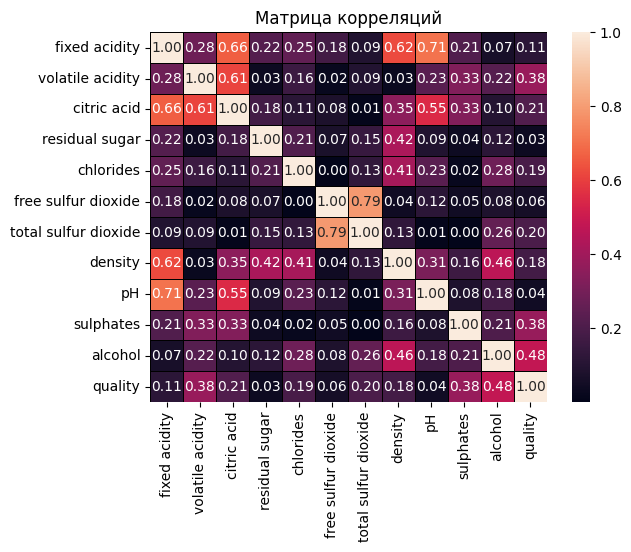

In [21]:
sns.heatmap(data.corr(numeric_only=True, method='spearman').abs(), annot=True, fmt=".2f", linewidths=.5, linecolor="black")
plt.title("Матрица корреляций")
plt.show()

In [4]:
# plt.figure(figsize=(15,7))

# cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

# sns.heatmap(data.isna().transpose(), cmap=cmap,
#             cbar_kws={'label': 'Missing Data'})
# plt.title("Пропущенные значения")
# plt.show()

In [5]:
key_list = []
for key in data:
    if (data[key].dtypes != 'object') :
        key_list.append(key)

Выбросы по колонке fixed acidity
205    12.8
206    12.8
243    15.0
244    15.0
264    12.5
Name: fixed acidity, dtype: float64
Выбросы по колонке volatile acidity
38     1.13
94     1.02
120    1.07
126    1.33
127    1.33
Name: volatile acidity, dtype: float64
Выбросы по колонке citric acid
151    1.0
Name: citric acid, dtype: float64
Выбросы по колонке residual sugar
9     6.1
11    6.1
14    3.8
15    3.9
18    4.4
Name: residual sugar, dtype: float64
Выбросы по колонке chlorides
14    0.176
15    0.170
17    0.368
19    0.341
38    0.172
Name: chlorides, dtype: float64
Выбросы по колонке free sulfur dioxide
14     52.0
15     51.0
57     50.0
396    68.0
400    68.0
Name: free sulfur dioxide, dtype: float64
Выбросы по колонке total sulfur dioxide
14    145.0
15    148.0
86    136.0
88    125.0
90    140.0
Name: total sulfur dioxide, dtype: float64
Выбросы по колонке density
142    0.9916
144    0.9916
294    1.0014
324    1.0015
325    1.0015
Name: density, dtype: float64
Выбросы

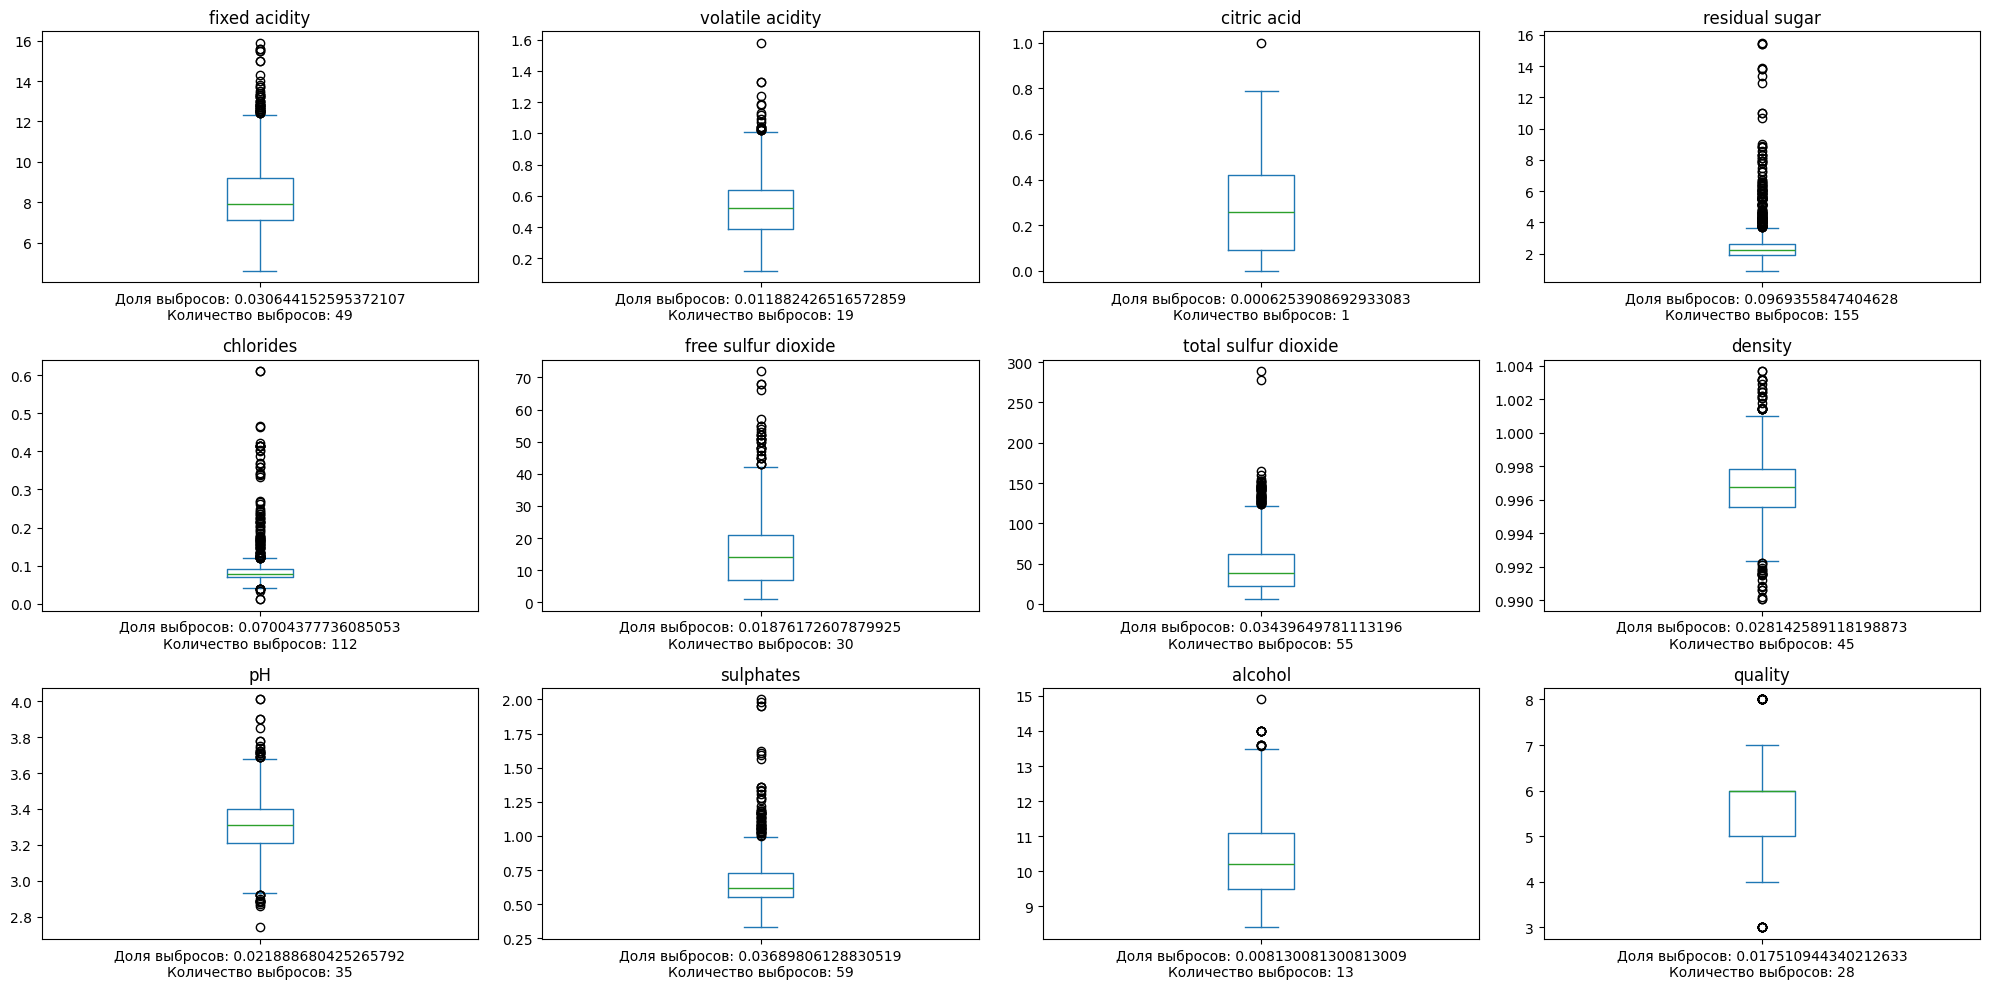

In [31]:
def get_outliers(data, key) :
    q1 = data[key].quantile(0.25)
    q3 = data[key].quantile(0.75)

    iqr = q3 - q1

    boxplot_range = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return data[(data[key] < boxplot_range[0]) | (data[key] > boxplot_range[1])]

fig, axes = plt.subplots(3, len(key_list) // 3, figsize=(20, 10))

for i in range(3) :
    for j in range(len(key_list) // 3) :
        outliers = get_outliers(data, key_list[i * len(key_list) // 3 + j])
        print(f'Выбросы по колонке {key_list[i * len(key_list) // 3 + j]}\n{outliers[key_list[i * len(key_list) // 3 + j]].head()}')
        data[key_list[i * len(key_list) // 3 + j]].plot(ax=axes[i, j], kind="box", label=f'Доля выбросов: {outliers.shape[0] / data.shape[0]}\nКоличество выбросов: {outliers.shape[0]}')
        axes[i, j].set_title(key_list[i * len(key_list) // 3 + j])

plt.tight_layout()
plt.show()

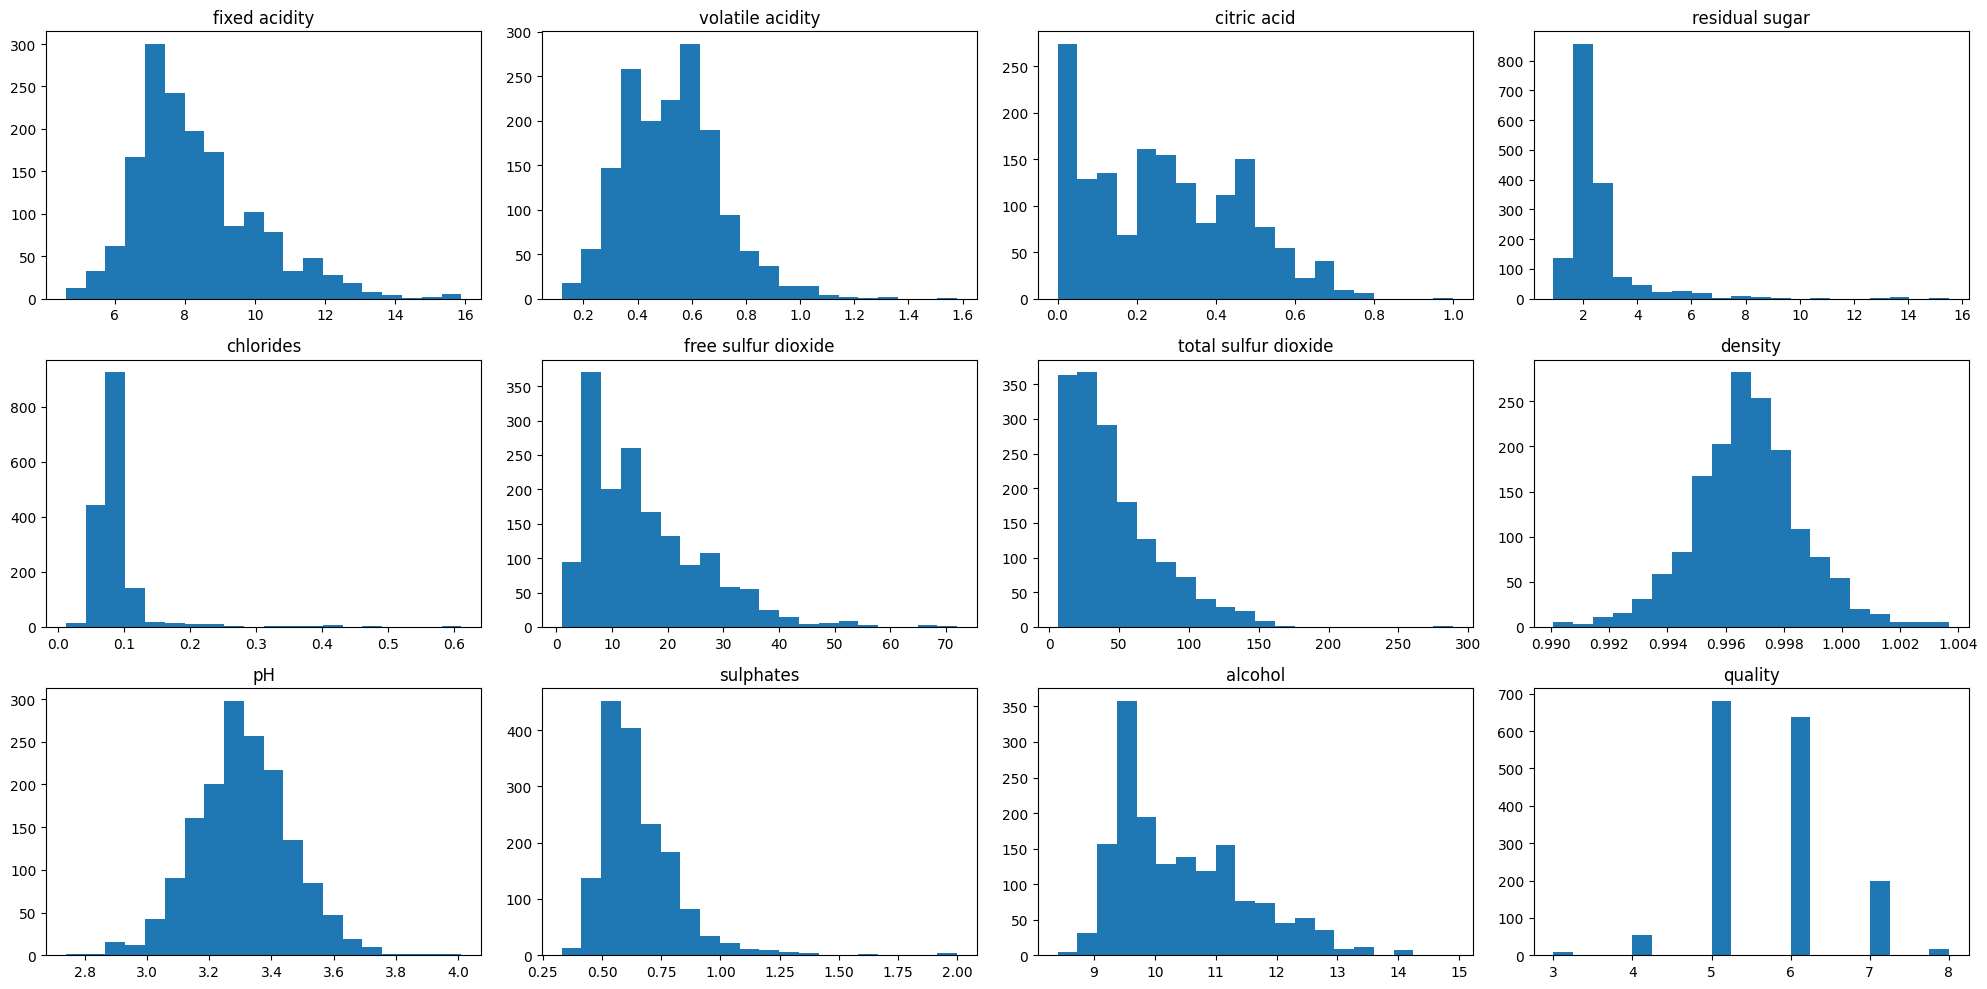

In [7]:
fig, axes = plt.subplots(3, len(key_list) // 3, figsize=(20, 10))

for i in range(3) :
    for j in range(len(key_list) // 3) :
        axes[i, j].hist(data[key_list[i * len(key_list) // 3 + j]], bins=20)
        axes[i, j].set_title(key_list[i * len(key_list) // 3 + j])

plt.tight_layout()
plt.show()

In [8]:
print(data.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

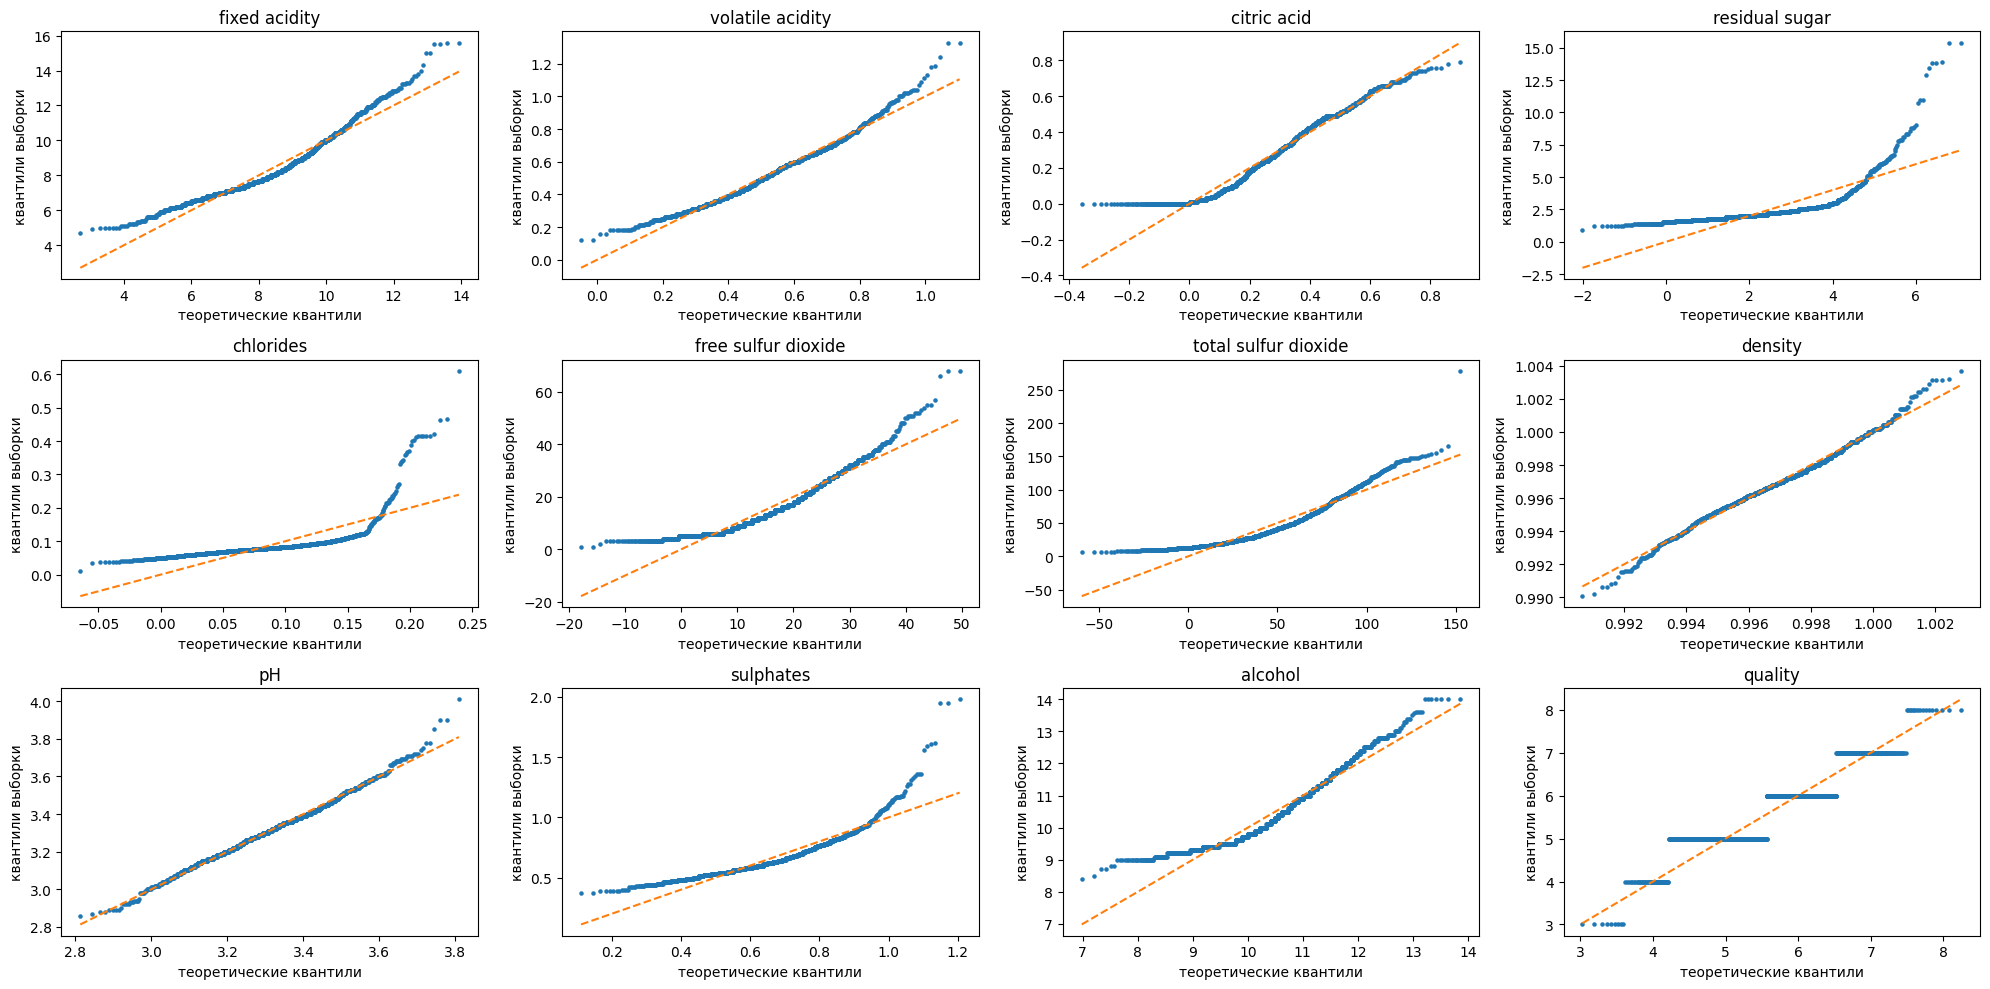

In [9]:

fig, axes = plt.subplots(3, len(key_list) // 3, figsize=(20, 10))

for i in range(3) :
    for j in range(len(key_list) // 3) :
        samples = data[key_list[i * len(key_list) // 3 + j]]
    
        loc = samples.mean()
        scale = samples.std()
    
        interval = np.linspace(0, 1, samples.shape[0])[1:-1]
        x = stats.norm.ppf(interval, loc=loc, scale=scale)
        y = np.quantile(samples, interval)
    
        axes[i, j].scatter(x, y, s=5)
        axes[i, j].plot(x, x, color='C1', linestyle='dashed')
    
        axes[i, j].set_title(key_list[i * len(key_list) // 3 + j])
        axes[i, j].set_xlabel('теоретические квантили')
        axes[i, j].set_ylabel('квантили выборки')

plt.tight_layout()

In [34]:
for key in key_list:
    print(key)
    
    samples = data[key]
    
    loc = samples.mean()
    scale = samples.std()

    for i in range(1, 4):
        true_value = stats.norm.cdf(i) - stats.norm.cdf(-i)
        sample_value = ((samples >= loc - i * scale) & (samples <= loc + i * scale)).sum() / samples.shape[0]
        
        print(f'{i} sigma(s)')
        print(f'\ttheoretical:\t{true_value}')
        print(f'\tsample:\t\t{sample_value}')
        
    print("")

fixed acidity
1 sigma(s)
	theoretical:	0.6826894921370859
	sample:		0.7398373983739838
2 sigma(s)
	theoretical:	0.9544997361036416
	sample:		0.9499687304565353
3 sigma(s)
	theoretical:	0.9973002039367398
	sample:		0.9924953095684803

volatile acidity
1 sigma(s)
	theoretical:	0.6826894921370859
	sample:		0.707942464040025
2 sigma(s)
	theoretical:	0.9544997361036416
	sample:		0.9649781113195748
3 sigma(s)
	theoretical:	0.9973002039367398
	sample:		0.9937460913070669

citric acid
1 sigma(s)
	theoretical:	0.6826894921370859
	sample:		0.5878674171357098
2 sigma(s)
	theoretical:	0.9544997361036416
	sample:		0.9781113195747342
3 sigma(s)
	theoretical:	0.9973002039367398
	sample:		0.9993746091307066

residual sugar
1 sigma(s)
	theoretical:	0.6826894921370859
	sample:		0.9136960600375235
2 sigma(s)
	theoretical:	0.9544997361036416
	sample:		0.9530956848030019
3 sigma(s)
	theoretical:	0.9973002039367398
	sample:		0.9812382739212008

chlorides
1 sigma(s)
	theoretical:	0.6826894921370859
	sample:	